In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"E:\superstore\Sample - Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [4]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [5]:
df = df.drop_duplicates()

In [6]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")


In [7]:
print(df.isna().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [8]:
critical_cols = ["Order Date", "Ship Date", "Order ID", "Product ID", "Sales"]
df = df.dropna(subset=critical_cols)

In [9]:
num_cols = ["Sales", "Quantity", "Discount", "Profit"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [10]:
df = df.dropna(subset=num_cols)


In [11]:
text_cols = [
    "Ship Mode", "Customer ID", "Customer Name", "Segment", "Country",
    "City", "State", "Region", "Product ID", "Category", "Sub-Category", "Product Name"
]
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

In [12]:
df = df[df["Sales"] >= 0]


In [13]:
# Total sales
total_sales = df["Sales"].sum()

# Total profit
total_profit = df["Profit"].sum()

# Number of orders
num_orders = df["Order ID"].nunique()

# Number of customers
num_customers = df["Customer ID"].nunique()

total_sales, total_profit, num_orders, num_customers

(np.float64(2297200.8603), np.float64(286397.0217), 5009, 793)

In [14]:
# Create a Year-Month column
df["YearMonth"] = df["Order Date"].dt.to_period("M")

sales_by_month = df.groupby("YearMonth")["Sales"].sum().reset_index()
sales_by_month.head()


,YearMonth,Sales
0,2014-01,14236.895
1,2014-02,4519.892
2,2014-03,55691.009
3,2014-04,28295.345
4,2014-05,23648.287


In [15]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
top_categories = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
top_regions = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

top_products, top_categories, top_regions


(Product Name
 Canon imageCLASS 2200 Advanced Copier                                          61599.824
 Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
 Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
 HON 5400 Series Task Chairs for Big and Tall                                   21870.576
 GBC DocuBind TL300 Electric Binding System                                     19823.479
 GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
 Hewlett Packard LaserJet 3310 Copier                                           18839.686
 HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
 GBC DocuBind P400 Electric Binding System                                      17965.068
 High Speed Automatic Electric Letter Opener                                    17030.312
 Name: Sales, dtype: float64,
 Category
 Technology         836154.0330
 Furniture    

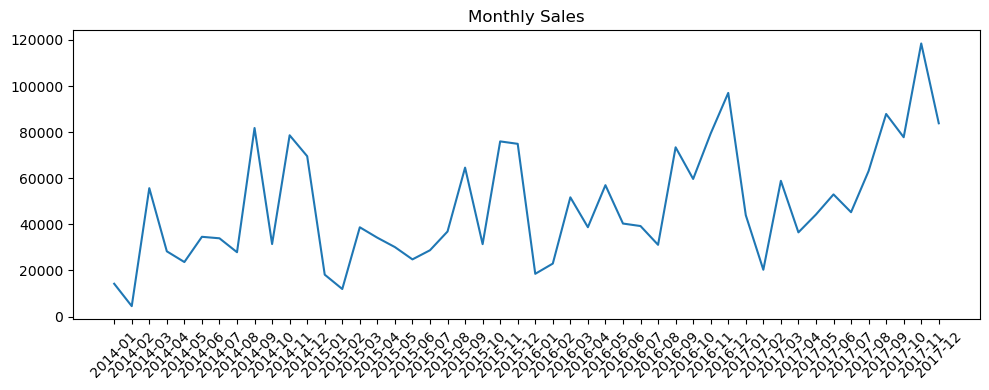

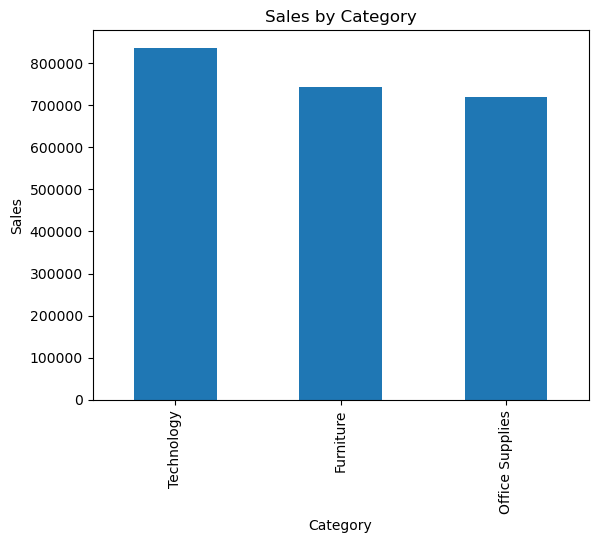

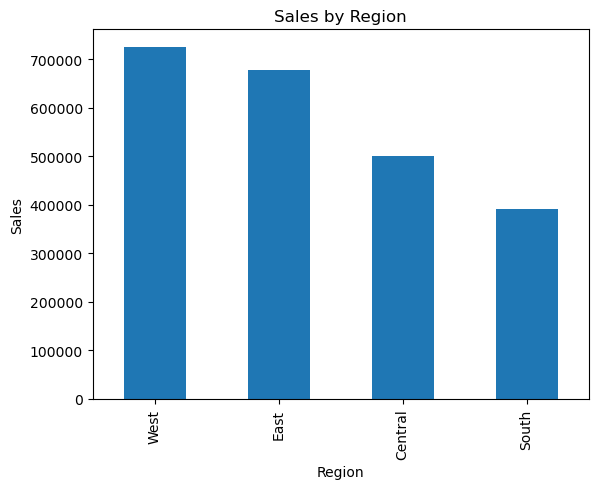

In [16]:
import matplotlib.pyplot as plt

# Sales by month
plt.figure(figsize=(10,4))
plt.plot(sales_by_month["YearMonth"].astype(str), sales_by_month["Sales"])
plt.xticks(rotation=45)
plt.title("Monthly Sales")
plt.tight_layout()
plt.show()

# Sales by category
top_categories.plot(kind="bar", title="Sales by Category")
plt.ylabel("Sales")
plt.show()

# Sales by region
top_regions.plot(kind="bar", title="Sales by Region")
plt.ylabel("Sales")
plt.show()

In [18]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
num_orders = df["Order ID"].nunique()
num_customers = df["Customer ID"].nunique()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Number of Orders:", num_orders)
print("Number of Customers:", num_customers)


Total Sales: 2297200.8603
Total Profit: 286397.0217
Number of Orders: 5009
Number of Customers: 793


In [19]:
sales_by_region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
sales_by_category = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
profit_by_category = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

print("Sales by Region:\n", sales_by_region, "\n")
print("Sales by Category:\n", sales_by_category, "\n")
print("Profit by Category:\n", profit_by_category, "\n")


Sales by Region:
 Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64 

Sales by Category:
 Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64 

Profit by Category:
 Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64 



In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Choose numeric columns relevant for business
num_cols = ["Sales", "Quantity", "Discount", "Profit"]

corr = df[num_cols].corr()
corr


,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


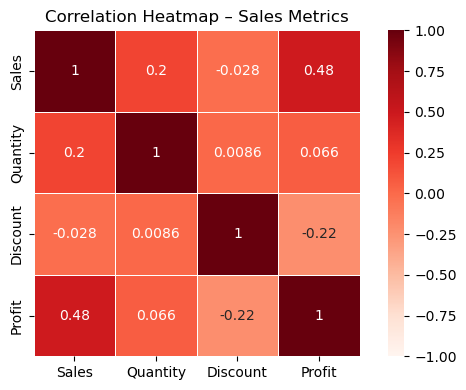

In [21]:
plt.figure(figsize=(6,4))
sns.heatmap(
    corr,
    annot=True,
    cmap="Reds",   # or "coolwarm"
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title("Correlation Heatmap – Sales Metrics")
plt.tight_layout()
plt.show()


In [22]:
summary = {
    "total_sales": df["Sales"].sum(),
    "total_profit": df["Profit"].sum(),
    "total_orders": df["Order ID"].nunique(),
    "total_customers": df["Customer ID"].nunique()
}

import pandas as pd
pd.DataFrame([summary]).to_csv("superstore_analysis_results.csv", index=False)


In [23]:
df.to_csv(r"E:\superstore\Sample_Superstore_cleaned.csv", index=False)


In [24]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [26]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,YearMonth
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016-11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016-11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016-06
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015-10
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015-10
